In [ ]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [ ]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)
print(cm)

[[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해, 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [ ]:
#실제 데이터에서 예측 데이터가 얼마나 같은지 직관적으로 모델예측 성능을 나타내는 지표
from sklearn.metrics import accuracy_score

acc = accuracy_score(y, y_pred)
print(acc)

#91퍼센트를 올바르게 예측했다
# 정확도가 1에 가까울 수록, 올바르게 예측했다고 할 수 있다.

0.9121265377855887


**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [ ]:
#예측을 positive로 한 대상 중에 예측과 실제 값이 positive로 일치한 데이터의 비율
from sklearn.metrics import precision_score

precision = precision_score(y, y_pred)
print(precision)

# positive로 예측한 것들 중 실제로 90퍼센트가 positive였다

0.900990099009901


**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [ ]:
#실제 값이 positive인 대상 중에 예측과 실제 값이 positive로 일치한 데이터의 비율
from sklearn.metrics import recall_score

recall = recall_score(y, y_pred)
print(recall)
# 실제 positive 중 올바르게 예측된 비율이 86퍼센트다.

0.8584905660377359


**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [ ]:
#정밀도와 재현율을 결합한 지표
from sklearn.metrics import f1_score

f1 = f1_score(y, y_pred)
print(f1)

# 정밀도와 재현율의 조화평균이 88퍼센트이다.
# 모델이 양성을 얼마나 잘 예측하면서도, 동시에 실제 양성을 얼마나 잘 찾아내는지에 대한 비율이 0.8792로 높은 편이다.

0.8792270531400966


**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [ ]:
from sklearn.preprocessing import Binarizer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

pred_proba = model_lor.predict_proba(X)
pred_proba_1 = pred_proba[:, 1].reshape(-1,1)
binarizer = Binarizer(threshold = 0.1)
y_pred2 = binarizer.fit_transform(pred_proba_1)

print(confusion_matrix(y, y_pred2))
print(accuracy_score(y, y_pred2))
print(precision_score(y, y_pred2))
print(recall_score(y, y_pred2))
print(f1_score(y, y_pred2))

[[267  90]
 [  6 206]]
0.8312829525483304
0.6959459459459459
0.9716981132075472
0.8110236220472441


In [ ]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기


**ROC 곡선 시각화**

In [ ]:
from sklearn.metrics import roc_curve


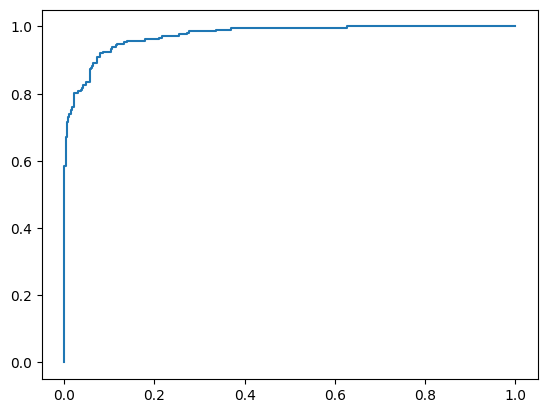

In [ ]:
import matplotlib.pyplot as plt

pred_proba_class1 = pred_proba[:, 1].reshape(-1,1)

fprs, tprs, thresholds = roc_curve(y, pred_proba_class1)

plt.plot(fprs, tprs)
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y, pred_proba_class1)
print(roc_auc)

# positive와 negative를 얼마나 잘 구분하는가를 보여주기에 97퍼센트의 확률로 구분됨을 알 수 있다.

0.974076423022039
